In [2]:
%matplotlib notebook
import time
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [16]:
env_hum = gym.make('CartPole-v1', render_mode = 'human')
env_hum.reset()

for step in range(1):
    #env_hum.render()
    action = env_hum.action_space.sample()
    observation, reward, terminated, truncated, info = env_hum.step(action)
    #time.sleep(0.02)

env_hum.close()

In [17]:
observation

array([ 0.01210017, -0.15160413, -0.02826754,  0.2447369 ], dtype=float32)

In [18]:
action

np.int64(0)

In [22]:
def create_bins(num_bins_per_obs = 10):
    bins_cart_position = np.linspace(-4.8, 4.8, num_bins_per_obs)
    bins_cart_velocity = np.linspace(-5, 5, num_bins_per_obs)
    bins_pole_angle = np.linspace(-0.418, 0.418, num_bins_per_obs)
    bins_pole_angular_velocity = np.linspace(-5, 5, num_bins_per_obs)

    bins = np.array([bins_cart_position, bins_cart_velocity, bins_pole_angle, bins_pole_angular_velocity])

    return bins

In [23]:
NUM_BINS = 10
BINS = create_bins(NUM_BINS)

In [24]:
BINS

array([[-4.8       , -3.73333333, -2.66666667, -1.6       , -0.53333333,
         0.53333333,  1.6       ,  2.66666667,  3.73333333,  4.8       ],
       [-5.        , -3.88888889, -2.77777778, -1.66666667, -0.55555556,
         0.55555556,  1.66666667,  2.77777778,  3.88888889,  5.        ],
       [-0.418     , -0.32511111, -0.23222222, -0.13933333, -0.04644444,
         0.04644444,  0.13933333,  0.23222222,  0.32511111,  0.418     ],
       [-5.        , -3.88888889, -2.77777778, -1.66666667, -0.55555556,
         0.55555556,  1.66666667,  2.77777778,  3.88888889,  5.        ]])

In [25]:
BINS.shape

(4, 10)

In [26]:
#np.digitize()

In [27]:
demo_bin = [0, 2, 4, 6, 8, 10]

In [28]:
demo_data = 1.1

In [29]:
np.digitize(demo_data, demo_bin)

np.int64(1)

In [30]:
np.digitize(9, demo_bin)

np.int64(5)

In [43]:
def discretize_observation(observations, bins):
    binned_observations = []

    for i,observation in enumerate(observations):
        discretized_observation = np.digitize(observation, bins[i])

        binned_observations.append(discretized_observation)
    return tuple(binned_observations)        

In [44]:
env = gym.make('CartPole-v1')

In [45]:
observations, info = env.reset()

In [46]:
observations

array([ 0.03657662, -0.00176241,  0.04162394,  0.02549434], dtype=float32)

In [47]:
mapped_observation = discretize_observation(observations, BINS)

In [48]:
mapped_observation

(np.int64(5), np.int64(5), np.int64(5), np.int64(5))

In [50]:
q_table_shape = (NUM_BINS, NUM_BINS, NUM_BINS, NUM_BINS, env.action_space.n)

In [51]:
q_table_shape

(10, 10, 10, 10, np.int64(2))

In [52]:
q_table = np.zeros(q_table_shape)

In [54]:
def epsilon_greedy_action_selection(epsilon, q_table, discrete_state):
    random_num = np.random.random()

    if random_num > epsilon:
        
        action = np.argmax(q_table[discrete_state])

    else:
        action = np.random.randint(0, env.action_space.n)

    return action

In [55]:
def compute_next_q_value(old_q_value, reward, next_optimal_q_value):
    return old_q_value + ALPHA * (reward + GAMMA*next_optimal_q_value - old_q_value)

In [56]:
EPOCHS = 20000
ALPHA = 0.8
GAMMA = 0.9

In [57]:
epsilon = 1.0

BURN_IN = 1
EPSILON_END = 10000
EPSILON_REDUCE = 0.0001

In [58]:
def reduce_epsilon(epsilon, epoch):
    if BURN_IN <= epoch <= EPSILON_END:
        epsilon -= EPSILON_REDUCE
    return epsilon

In [59]:
def fail(done, points, reward):
    if done and points < 150:
        reward = -200
    return reward

In [62]:
from IPython.display import clear_output, display

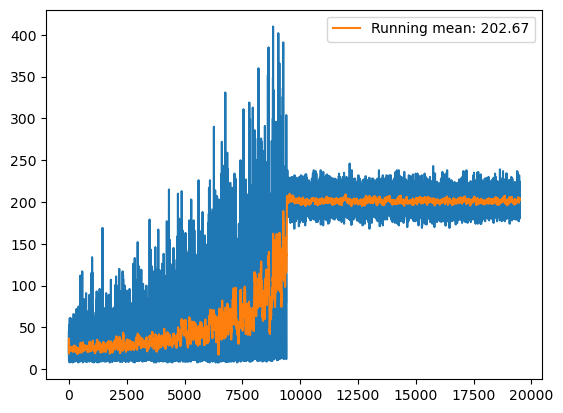

In [63]:
log_interval = 500
render_interval = 30000

fig = plt.figure()
ax = fig.add_subplot(111)
fig.canvas.draw()

points_log = []
mean_points_log = []
epochs = []

for epoch in range(EPOCHS):
    initial_state, info = env.reset()
    discretized_state = discretize_observation(initial_state, BINS)

    done = False
    points = 0

    epochs.append(epoch)

    while not done:
        action = epsilon_greedy_action_selection(epsilon, q_table, discretized_state)
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        reward = fail(done, points, reward)
        next_state_discretized = discretize_observation(next_state, BINS)

        old_q_value = q_table[discretized_state + (action,)]
        next_optimal_q_value = np.max(q_table[next_state_discretized])

        next_q = compute_next_q_value(old_q_value, reward, next_optimal_q_value)
        q_table[discretized_state + (action,)] = next_q

        discretized_state = next_state_discretized
        points += 1

    epsilon = reduce_epsilon(epsilon, epoch)
    points_log.append(points)
    running_mean = round(np.mean(points_log[-30:]), 2)
    mean_points_log.append(running_mean)

    if epoch % log_interval == 0:
        clear_output(wait=True)
        ax.clear()
        ax.plot(epochs, points_log)
        ax.plot(epochs, mean_points_log, label=f"Running mean: {running_mean}")
        plt.legend()
        display(fig)

In [66]:
env_hum = gym.make('CartPole-v1', render_mode = 'human')
observation, info = env_hum.reset()
rewards = 0

for step in range(1000):
    env_hum.render()
    discrete_state = discretize_observation(observation, BINS)
    action = np.argmax(q_table[discrete_state])
    observation, reward, terminated, truncated, info = env_hum.step(action)
    rewards += 1

    if terminated or truncated:
        print(f"You got {rewards} points!")
        break

You got 201 points!
